# Step 1: Load, parse and merge data files

In [1]:
"""
FIT5196 - Data Wrangling | Assessment 1 | Group 4
------------------------------------------------------------------------
Pipeline: Load → Rename → Merge → Deduplicate → Clean → Standardise → Export
"""

# =============================================================================
# SECTION 1 — IMPORTS
# =============================================================================
import re
import json
import numpy as np
import pandas as pd
from lxml import etree

# =============================================================================
# SECTION 2 — COMPILE REGEX PATTERNS (once at module level for performance)
# =============================================================================

# Strip XML/HTML tags: matches anything of the form <...>
TAG_RE = re.compile(r'<[^>]+>', re.UNICODE)

# Strip emojis — all major Unicode emoji blocks
EMOJI_RE = re.compile(
    "["
    "\U0001F600-\U0001F64F"   # Emoticons
    "\U0001F300-\U0001F5FF"   # Misc Symbols & Pictographs
    "\U0001F680-\U0001F6FF"   # Transport & Map Symbols
    "\U0001F700-\U0001F77F"   # Alchemical Symbols
    "\U0001F780-\U0001F7FF"   # Geometric Shapes Extended
    "\U0001F800-\U0001F8FF"   # Supplemental Arrows-C
    "\U0001F900-\U0001F9FF"   # Supplemental Symbols & Pictographs
    "\U0001FA00-\U0001FA6F"   # Chess Symbols
    "\U0001FA70-\U0001FAFF"   # Symbols & Pictographs Extended-A
    "\U00002600-\U000026FF"   # Miscellaneous Symbols
    "\U00002700-\U000027BF"   # Dingbats
    "\U0000FE00-\U0000FE0F"   # Variation Selectors
    "\U0001F1E0-\U0001F1FF"   # Regional Indicator Symbols (flags)
    "\U00002300-\U000023FF"   # Miscellaneous Technical
    "\U00002B50-\U00002B55"   # Stars/circles
    "\U0000200D"               # Zero-Width Joiner
    "\U0000FE0F"               # Variation Selector-16
    "]+",
    flags=re.UNICODE
)

# Remove non-Latin characters. Retains:
#   \x20-\x7E       : ASCII printable (A-Z, 0-9, punctuation)
#   \u00A0-\u024F   : Latin-1 Supplement + Latin Extended A/B
#                     (à, é, ü, ñ, ø, ć, ž, đ ...)
#   \u1E00-\u1EFF   : Latin Extended Additional (ṣ, ẃ ...)
# Removes: Cyrillic, CJK, Arabic, Hebrew, Devanagari, etc.
NON_LATIN_RE = re.compile(
    r'[^\x20-\x7E\u00A0-\u024F\u1E00-\u1EFF]',
    re.UNICODE
)

# =============================================================================
# SECTION 3 — CANONICAL SCHEMA  (matches sample output exactly)
# =============================================================================

COLUMNS_ORDERED = [
    'Post_ID', 'User_ID', 'Secret', 'Server', 'Title',
    'Is_Public', 'Is_Friend', 'Is_Family', 'Farm',
    'City', 'Country', 'Post_Date', 'Taken_Date',
    'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date'
]

# Columns whose TEXT VALUES are lowercased (column names stay as-is)
LOWER_COLS = ['Title', 'City', 'Country', 'Tags', 'Description']

# All numeric columns stored as float64 — matches sample output (e.g. 65535.0)
FLOAT_COLS = ['Post_ID', 'Server', 'Farm', 'Is_Public',
              'Is_Friend', 'Is_Family', 'Latitude', 'Longitude']

# Rename map: XML raw field names → canonical column names
XML_RENAME = {
    'PostID':         'Post_ID',
    'UserID':         'User_ID',
    'secret':         'Secret',
    'server':         'Server',
    'title':          'Title',
    'ispublic':       'Is_Public',
    'isfriend':       'Is_Friend',
    'isfamily':       'Is_Family',
    'farm':           'Farm',
    'City':           'City',
    'Country':        'Country',
    'Post_date':      'Post_Date',
    'Taken_date':     'Taken_Date',
    'tags':           'Tags',
    'latitude':       'Latitude',
    'longitude':      'Longitude',
    'description':    'Description',
    'min_taken_date': 'Min_Taken_Date',
}

# Rename map: JSON raw field names → canonical column names
JSON_RENAME = {
    'PostID':         'Post_ID',
    'UserID':         'User_ID',
    'secret':         'Secret',
    'server':         'Server',
    'title':          'Title',
    'ispublic':       'Is_Public',
    'isfriend':       'Is_Friend',
    'isfamily':       'Is_Family',
    'farm':           'Farm',
    'City':           'City',
    'Country':        'Country',
    'Post date':      'Post_Date',
    'Taken date':     'Taken_Date',
    'tags':           'Tags',
    'latitude':       'Latitude',
    'longitude':      'Longitude',
    'description':    'Description',
    'min_taken_date': 'Min_Taken_Date',
}

# =============================================================================
# SECTION 4 — DATA LOADING
# =============================================================================

def parse_xml(filepath: str) -> pd.DataFrame:
    """
    Load group_4.xml via lxml.etree.iterparse (memory-efficient streaming).
    Each <Record> is processed and immediately cleared from memory.
    Falls back to recover=True for malformed/truncated XML.
    Field names are renamed to the canonical schema via XML_RENAME.
    """
    records = []
    try:
        context = etree.iterparse(filepath, events=('end',), tag='Record')
        for _, elem in context:
            record = {child.tag: child.text for child in elem}
            records.append(record)
            elem.clear()
            parent = elem.getparent()
            if parent is not None:
                parent.remove(elem)
    except etree.XMLSyntaxError:
        parser = etree.XMLParser(recover=True, encoding='utf-8')
        tree   = etree.parse(filepath, parser)
        root   = tree.getroot()
        for elem in root.findall('Record'):
            record = {child.tag: child.text for child in elem}
            records.append(record)

    df = pd.DataFrame(records)
    df = df.rename(columns=XML_RENAME)
    return df


def parse_json(filepath: str) -> pd.DataFrame:
    """
    Load group_4.json via json.load (preserves native Python types).
    Field names are renamed to the canonical schema via JSON_RENAME.
    """
    with open(filepath, 'r', encoding='utf-8') as fh:
        data = json.load(fh)
    df = pd.DataFrame(data)
    df = df.rename(columns=JSON_RENAME)
    return df


# =============================================================================
# SECTION 5 — DTYPE NORMALISATION
# =============================================================================

def normalise_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Coerce all numeric columns to float64.
    Sample output stores Post_ID as 52049721185.0, Server as 65535.0, etc.
    Using float (not Int64) matches that format exactly.
    """
    for col in FLOAT_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


# =============================================================================
# SECTION 6 — TEXT CLEANING (Regex only — per spec)
# =============================================================================

def clean_text(value) -> object:
    """
    Three sequential regex passes on a single string value:
      1. Strip XML/HTML tags
      2. Strip emoji characters
      3. Strip non-Latin characters (retains European extended Latin)
    Returns None if result is empty; non-string/null inputs return None.
    """
    if value is None:
        return None
    if isinstance(value, float) and np.isnan(value):
        return None
    if not isinstance(value, str):
        value = str(value)

    value = TAG_RE.sub('', value)
    value = EMOJI_RE.sub('', value)
    value = NON_LATIN_RE.sub('', value)
    value = value.strip()

    return value if value else None


def apply_text_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    """Apply clean_text() to all string columns; skip numeric columns."""
    skip = set(FLOAT_COLS)
    for col in df.columns:
        if col not in skip:
            df[col] = df[col].map(clean_text)
    return df


def apply_lowercase(df: pd.DataFrame) -> pd.DataFrame:
    """
    Lowercase Title, City, Country, Tags, Description.
    Only applied to actual string values — NaN/None skipped per spec.
    """
    for col in LOWER_COLS:
        if col in df.columns:
            df[col] = df[col].map(
                lambda x: x.lower() if isinstance(x, str) else x
            )
    return df


# =============================================================================
# SECTION 7 — NULL STANDARDISATION
# =============================================================================

def standardise_nulls(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replace ALL null representations with the string literal 'NaN'.
    Handles: Python None, np.nan, pandas NA, empty strings,
             residual 'nan'/'none'/'null' strings.
    """
    _NULL_STRINGS = frozenset(['nan', 'none', 'null', ''])

    def _to_nan_str(x):
        if x is None:
            return 'NaN'
        if isinstance(x, float) and np.isnan(x):
            return 'NaN'
        if isinstance(x, str) and x.strip().lower() in _NULL_STRINGS:
            return 'NaN'
        return x

    for col in df.columns:
        df[col] = df[col].map(_to_nan_str)

    return df


# =============================================================================
# SECTION 8 — MAIN PIPELINE
# =============================================================================

def run_pipeline(xml_path:    str = 'group_4.xml',
                 json_path:   str = 'group_4.json',
                 output_path: str = 'Group4_dataset.csv') -> pd.DataFrame:
    """
    Full data wrangling pipeline:
      1.  Parse XML  → DataFrame (with canonical column names)
      2.  Parse JSON → DataFrame (with canonical column names)
      3.  Normalise dtypes (float64 for numeric columns)
      4.  Concatenate + deduplicate on Post_ID
      5.  Enforce 18-column canonical schema and ordering
      6.  Regex text cleaning (tags, emojis, non-Latin) on all string cols
      7.  Lowercase: Title, City, Country, Tags, Description
      8.  Standardise all nulls → string 'NaN'
      9.  Validate schema
      10. Export to CSV
    """
    # Step 1 & 2 — Load
    print("Loading XML ...")
    df_xml  = parse_xml(xml_path)
    print(f"  XML records loaded  : {len(df_xml):,}")

    print("Loading JSON ...")
    df_json = parse_json(json_path)
    print(f"  JSON records loaded : {len(df_json):,}")

    # Step 3 — Normalise dtypes
    df_xml  = normalise_dtypes(df_xml)
    df_json = normalise_dtypes(df_json)

    # Step 4 — Merge & deduplicate
    df = pd.concat([df_xml, df_json], ignore_index=True)
    before = len(df)
    df = df.drop_duplicates(subset=['Post_ID'], keep='first')
    after  = len(df)
    print(f"\nRecords after concat      : {before:,}")
    print(f"Duplicate Post_IDs removed : {before - after:,}")
    print(f"Records after dedup        : {after:,}")

    # Step 5 — Enforce schema
    missing = [c for c in COLUMNS_ORDERED if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns after merge: {missing}")
    df = df[COLUMNS_ORDERED].copy()

    # Step 6 — Regex text cleaning
    print("\nApplying regex text cleaning ...")
    df = apply_text_cleaning(df)

    # Step 7 — Lowercase
    print("Applying lowercase transformation ...")
    df = apply_lowercase(df)

    # Step 8 — Null standardisation
    print("Standardising null values to 'NaN' ...")
    df = standardise_nulls(df)

    # Step 9 — Validate
    assert list(df.columns) == COLUMNS_ORDERED, \
        f"Schema mismatch: {list(df.columns)}"
    assert len(df.columns) == 18, \
        f"Expected 18 columns, got {len(df.columns)}"
    print(f"\nSchema validated — {len(df.columns)} columns, {len(df):,} records")

    # Step 10 — Export
    df.to_csv(output_path, index=False, encoding='utf-8')
    print(f"Output saved → {output_path}")

    return df


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == '__main__':
    df_final = run_pipeline()

Loading XML ...
  XML records loaded  : 14,720
Loading JSON ...
  JSON records loaded : 29,440

Records after concat      : 44,160
Duplicate Post_IDs removed : 11,268
Records after dedup        : 32,892

Applying regex text cleaning ...
Applying lowercase transformation ...
Standardising null values to 'NaN' ...

Schema validated — 18 columns, 32,892 records
Output saved → Group4_dataset.csv


# Step 2 - Apply EDA on the merged dataset with visualizations

## Block 1 — Dataset Structure & Sanity Checks

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('Group4_dataset.csv', dtype=str, keep_default_na=False)

# ── 1.1 Basic dimensions ──────────────────────────────────────────
print("=== 1.1 DATASET DIMENSIONS ===")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"Total cells : {df.shape[0] * df.shape[1]:,}")

# ── 1.2 Column data types ─────────────────────────────────────────
print("\n=== 1.2 COLUMN DATA TYPES ===")
print(df.dtypes)

# ── 1.3 Missing value summary ─────────────────────────────────────
print("\n=== 1.3 MISSING VALUES (NaN string) ===")
nan_counts = (df == 'NaN').sum()
nan_pct    = (nan_counts / len(df) * 100).round(1)
missing_df = pd.DataFrame({'NaN_Count': nan_counts, 'NaN_%': nan_pct})
missing_df = missing_df[missing_df['NaN_Count'] > 0].sort_values('NaN_%', ascending=False)
print(missing_df.to_string())

# ── 1.4 Duplicate check ───────────────────────────────────────────
print("\n=== 1.4 DUPLICATE CHECK ===")
print(f"Full duplicate rows : {df.duplicated().sum()}")
print(f"Duplicate Post_IDs  : {df.duplicated(subset=['Post_ID']).sum()}")

# ── 1.5 Descriptive stats on numeric columns ──────────────────────
numeric_cols = ['Latitude', 'Longitude']
df_num = df.copy()
for col in numeric_cols:
    df_num[col] = pd.to_numeric(df_num[col].replace('NaN', np.nan), errors='coerce')

print("\n=== 1.5 DESCRIPTIVE STATISTICS (Numeric) ===")
print(df_num[numeric_cols].describe().round(4).to_string())

# ── 1.6 Unique value counts ───────────────────────────────────────
print("\n=== 1.6 UNIQUE VALUE COUNTS ===")
for col in df.columns:
    non_nan = df[df[col] != 'NaN'][col]
    print(f"  {col:18}: {non_nan.nunique():>6} unique values")

# ── 1.7 Is_Public / Is_Friend / Is_Family distributions ──────────
print("\n=== 1.7 BINARY COLUMN DISTRIBUTIONS ===")
for col in ['Is_Public', 'Is_Friend', 'Is_Family']:
    print(f"\n  {col}:")
    print(df[df[col] != 'NaN'][col].value_counts().to_string())

=== 1.1 DATASET DIMENSIONS ===
Rows    : 32,892
Columns : 18
Total cells : 592,056

=== 1.2 COLUMN DATA TYPES ===
Post_ID           str
User_ID           str
Secret            str
Server            str
Title             str
Is_Public         str
Is_Friend         str
Is_Family         str
Farm              str
City              str
Country           str
Post_Date         str
Taken_Date        str
Tags              str
Latitude          str
Longitude         str
Description       str
Min_Taken_Date    str
dtype: object

=== 1.3 MISSING VALUES (NaN string) ===
             NaN_Count  NaN_%
Description      18962   57.6
City             18328   55.7
Country          17541   53.3
Tags             10134   30.8
Title             2178    6.6
Post_ID              1    0.0
User_ID              1    0.0
Secret               1    0.0
Server               1    0.0
Is_Public            1    0.0
Is_Friend            1    0.0
Is_Family            1    0.0
Farm                 1    0.0
Taken_Date     

## Block 2 — Univariate: Numeric columns

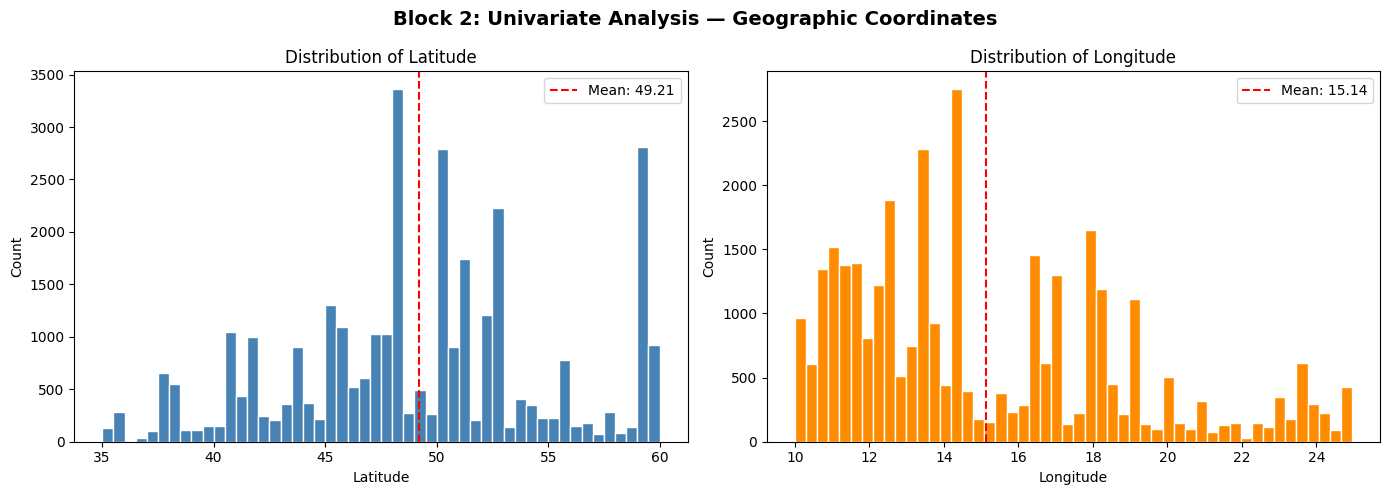

Block 2 chart saved.

=== BLOCK 2: Coordinate Summary ===
         Latitude   Longitude
count  32891.0000  32891.0000
mean      49.2109     15.1426
std        5.8983      3.7672
min       35.0141     10.0000
25%       45.4862     12.2401
50%       49.2975     14.2526
75%       52.5153     18.0117
max       59.9862     24.9585

Latitude  — skewness : -0.0250
Longitude — skewness : 0.7899


In [3]:
# ── BLOCK 2: Univariate Analysis — Numeric Columns ────────────────

# Convert numeric columns properly
df_num = df.copy()
for col in ['Latitude', 'Longitude']:
    df_num[col] = pd.to_numeric(df_num[col].replace('NaN', np.nan), errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Block 2: Univariate Analysis — Geographic Coordinates', fontsize=14, fontweight='bold')

# Latitude distribution
axes[0].hist(df_num['Latitude'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Latitude')
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel('Count')
axes[0].axvline(df_num['Latitude'].mean(), color='red', linestyle='--', label=f"Mean: {df_num['Latitude'].mean():.2f}")
axes[0].legend()

# Longitude distribution
axes[1].hist(df_num['Longitude'].dropna(), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Longitude')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Count')
axes[1].axvline(df_num['Longitude'].mean(), color='red', linestyle='--', label=f"Mean: {df_num['Longitude'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('block2_lat_lon_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Block 2 chart saved.")

# Print summary stats for verification
print("\n=== BLOCK 2: Coordinate Summary ===")
print(df_num[['Latitude','Longitude']].describe().round(4).to_string())
print(f"\nLatitude  — skewness : {df_num['Latitude'].skew():.4f}")
print(f"Longitude — skewness : {df_num['Longitude'].skew():.4f}")

## Block 3 — Univariate: Categorical columns

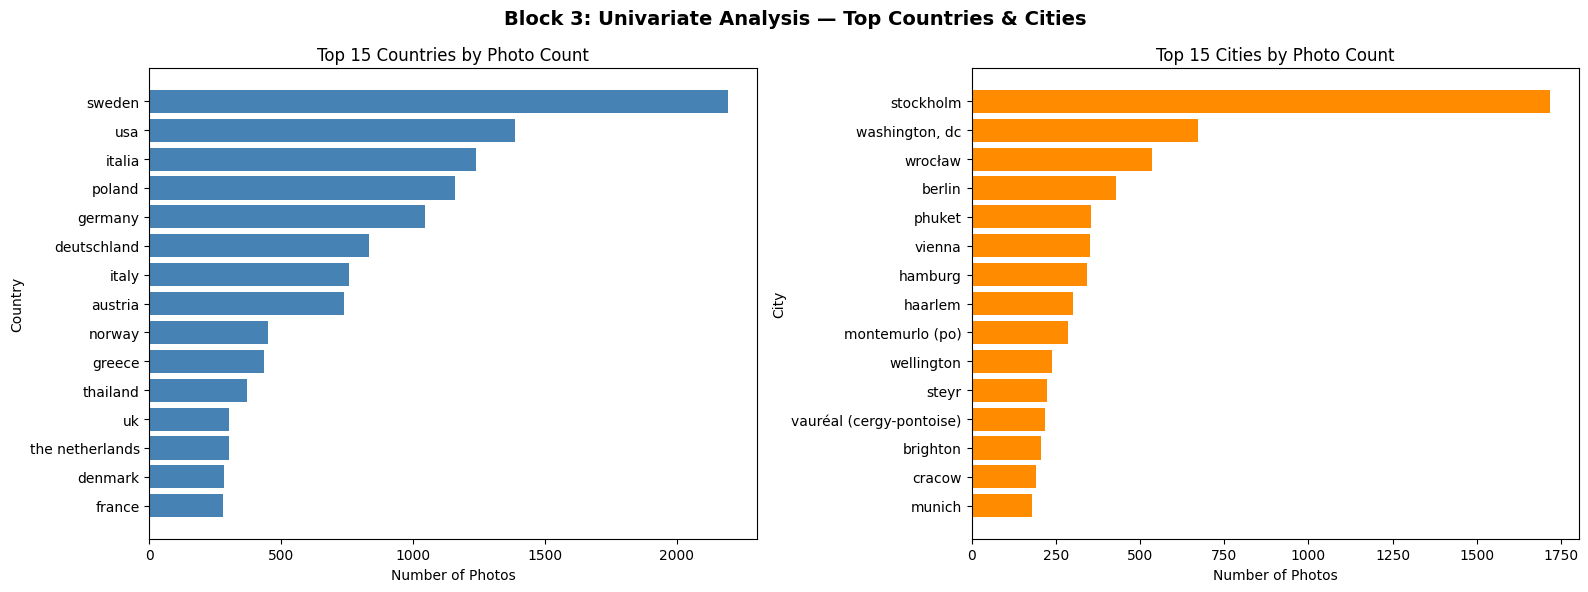

Block 3 chart saved.

=== BLOCK 3: Country Value Counts (Top 15) ===
Country
sweden             2195
usa                1387
italia             1238
poland             1158
germany            1047
deutschland         832
italy               758
austria             739
norway              451
greece              435
thailand            372
uk                  303
the netherlands     302
denmark             282
france              281

=== BLOCK 3: City Value Counts (Top 15) ===
City
stockholm                   1717
washington, dc               671
wrocław                      535
berlin                       429
phuket                       356
vienna                       351
hamburg                      344
haarlem                      302
montemurlo (po)              286
wellington                   240
steyr                        223
vauréal (cergy-pontoise)     219
brighton                     206
cracow                       190
munich                       181

=== BLOCK 3: User

In [4]:
# ── BLOCK 3: Univariate Analysis — Categorical Columns ────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Block 3: Univariate Analysis — Top Countries & Cities', fontsize=14, fontweight='bold')

# Top 15 Countries
country_counts = df[df['Country'] != 'NaN']['Country'].value_counts().head(15)
axes[0].barh(country_counts.index[::-1], country_counts.values[::-1], color='steelblue')
axes[0].set_title('Top 15 Countries by Photo Count')
axes[0].set_xlabel('Number of Photos')
axes[0].set_ylabel('Country')

# Top 15 Cities
city_counts = df[df['City'] != 'NaN']['City'].value_counts().head(15)
axes[1].barh(city_counts.index[::-1], city_counts.values[::-1], color='darkorange')
axes[1].set_title('Top 15 Cities by Photo Count')
axes[1].set_xlabel('Number of Photos')
axes[1].set_ylabel('City')

plt.tight_layout()
plt.savefig('block3_country_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("Block 3 chart saved.")

# User activity distribution
print("\n=== BLOCK 3: Country Value Counts (Top 15) ===")
print(country_counts.to_string())

print("\n=== BLOCK 3: City Value Counts (Top 15) ===")
print(city_counts.to_string())

print("\n=== BLOCK 3: User Activity ===")
user_post_counts = df[df['User_ID'] != 'NaN']['User_ID'].value_counts()
print(f"Total unique users     : {user_post_counts.shape[0]}")
print(f"Max posts by one user  : {user_post_counts.max()}")
print(f"Median posts per user  : {user_post_counts.median()}")
print(f"Mean posts per user    : {user_post_counts.mean():.2f}")
print(f"\nTop 10 most active users:")
print(user_post_counts.head(10).to_string())

## Block 4 — Univariate: Datetime columns

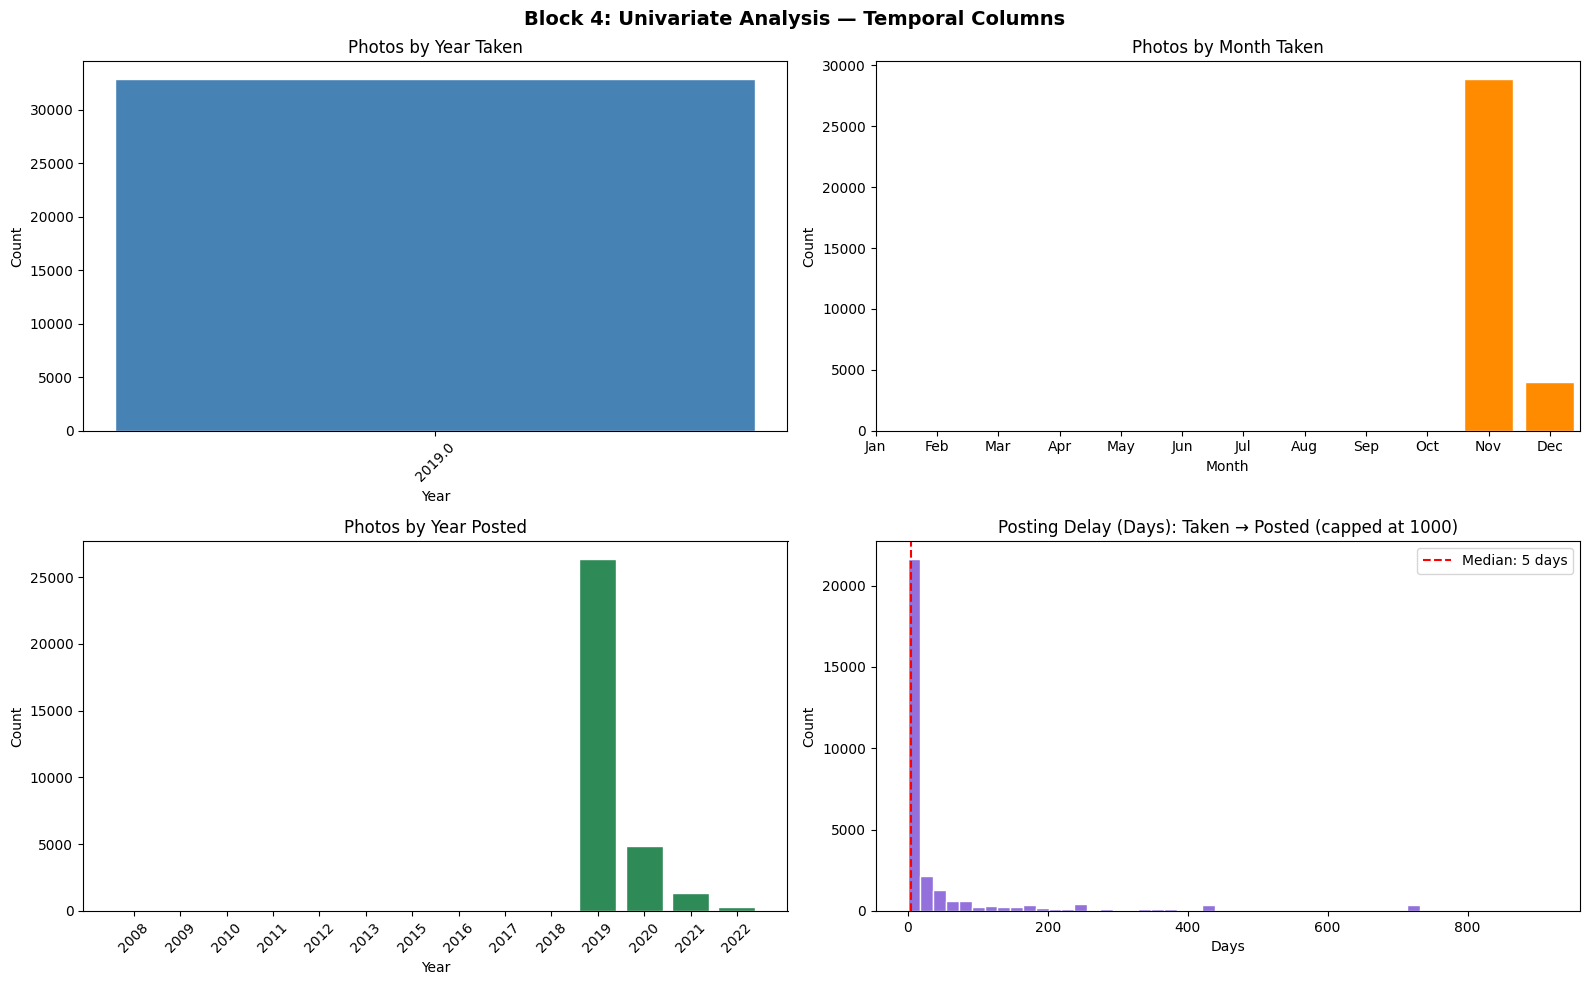

Block 4 chart saved.

=== BLOCK 4: Temporal Summary ===
Photos Taken — year range : 2019 to 2019
Photos Posted — year range: 2008 to 2022

Photos by Year Taken:
Taken_Year
2019.0    32891

Photos by Month Taken:
Taken_Month
11.0    28882
12.0     4009

Photos by Year Posted:
Post_Year
2008        4
2009        3
2010       11
2011        2
2012        1
2013        1
2015        2
2016        8
2017        7
2018        6
2019    26348
2020     4885
2021     1345
2022      269

Posting Delay Stats (days):
  Min    : 0
  Median : 5
  Mean   : 60.8
  Max    : 915
  % posted same day (0 days): 26.8%
  % posted within 7 days    : 57.5%
  % posted after 1 year     : 5.8%


In [5]:
# ── BLOCK 4: Univariate Analysis — Datetime Columns ───────────────

# Parse dates
df_time = df.copy()
df_time['Post_Date']   = pd.to_datetime(df_time['Post_Date'],   errors='coerce')
df_time['Taken_Date']  = pd.to_datetime(df_time['Taken_Date'],  errors='coerce')

# Extract year and month
df_time['Taken_Year']  = df_time['Taken_Date'].dt.year
df_time['Taken_Month'] = df_time['Taken_Date'].dt.month
df_time['Post_Year']   = df_time['Post_Date'].dt.year

# Posting delay in days
df_time['Posting_Delay_Days'] = (df_time['Post_Date'] - df_time['Taken_Date']).dt.days

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Block 4: Univariate Analysis — Temporal Columns', fontsize=14, fontweight='bold')

# Photos taken by year
taken_year = df_time['Taken_Year'].value_counts().sort_index()
axes[0, 0].bar(taken_year.index.astype(str), taken_year.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Photos by Year Taken')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Photos taken by month
taken_month = df_time['Taken_Month'].value_counts().sort_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0, 1].bar(taken_month.index, taken_month.values, color='darkorange', edgecolor='white')
axes[0, 1].set_title('Photos by Month Taken')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_labels)

# Photos posted by year
post_year = df_time['Post_Year'].value_counts().sort_index()
axes[1, 0].bar(post_year.index.astype(str), post_year.values, color='seagreen', edgecolor='white')
axes[1, 0].set_title('Photos by Year Posted')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Posting delay distribution
valid_delay = df_time['Posting_Delay_Days'].dropna()
valid_delay = valid_delay[valid_delay >= 0]
axes[1, 1].hist(valid_delay.clip(upper=1000), bins=50, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Posting Delay (Days): Taken → Posted (capped at 1000)')
axes[1, 1].set_xlabel('Days')
axes[1, 1].set_ylabel('Count')
axes[1, 1].axvline(valid_delay.median(), color='red', linestyle='--',
                   label=f'Median: {valid_delay.median():.0f} days')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('block4_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Block 4 chart saved.")

print("\n=== BLOCK 4: Temporal Summary ===")
print(f"Photos Taken — year range : {int(df_time['Taken_Year'].min())} to {int(df_time['Taken_Year'].max())}")
print(f"Photos Posted — year range: {int(df_time['Post_Year'].min())} to {int(df_time['Post_Year'].max())}")
print(f"\nPhotos by Year Taken:")
print(taken_year.to_string())
print(f"\nPhotos by Month Taken:")
print(taken_month.to_string())
print(f"\nPhotos by Year Posted:")
print(post_year.to_string())
print(f"\nPosting Delay Stats (days):")
print(f"  Min    : {valid_delay.min():.0f}")
print(f"  Median : {valid_delay.median():.0f}")
print(f"  Mean   : {valid_delay.mean():.1f}")
print(f"  Max    : {valid_delay.max():.0f}")
print(f"  % posted same day (0 days): {(valid_delay == 0).sum() / len(valid_delay) * 100:.1f}%")
print(f"  % posted within 7 days    : {(valid_delay <= 7).sum() / len(valid_delay) * 100:.1f}%")
print(f"  % posted after 1 year     : {(valid_delay > 365).sum() / len(valid_delay) * 100:.1f}%")

## Block 5 — Univariate: Text columns

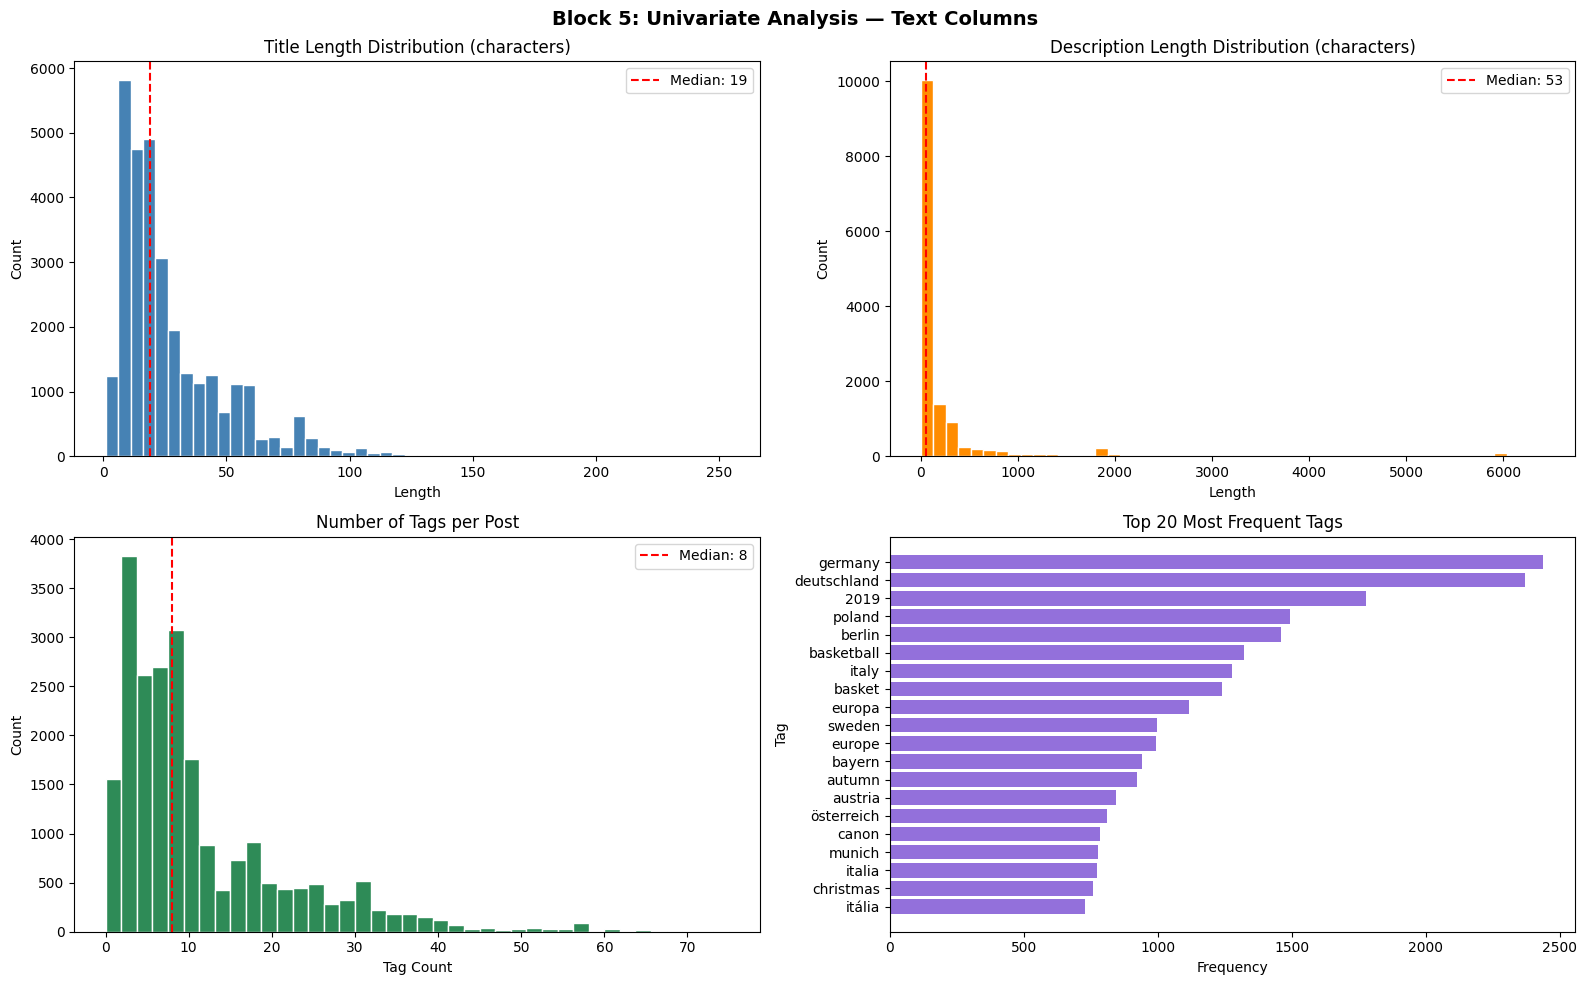

Block 5 chart saved.

=== BLOCK 5: Text Column Summary ===

Title Length:
  Non-NaN count : 30,714
  Mean          : 28.2 chars
  Median        : 19 chars
  Max           : 254 chars

Description Length:
  Non-NaN count : 13,930
  Mean          : 249.6 chars
  Median        : 53 chars
  Max           : 6423 chars

Tags per Post:
  Non-NaN count : 22,758
  Mean          : 11.4 tags
  Median        : 8 tags
  Max           : 75 tags

Total unique tags  : 23,778
Total tag instances: 258,509

Top 20 Tags:
germany        2437
deutschland    2370
2019           1777
poland         1495
berlin         1459
basketball     1322
italy          1279
basket         1241
europa         1116
sweden          997
europe          994
bayern          940
autumn          921
austria         844
österreich      812
canon           784
munich          776
italia          775
christmas       758
itália          727


In [6]:
# ── BLOCK 5: Univariate Analysis — Text Columns ───────────────────

# Title length
df_text = df.copy()
df_text['Title_Len'] = df_text['Title'].apply(
    lambda x: len(x) if x != 'NaN' else np.nan)
df_text['Desc_Len'] = df_text['Description'].apply(
    lambda x: len(x) if x != 'NaN' else np.nan)

# Tags count
df_text['Tags_Count'] = df_text['Tags'].apply(
    lambda x: len([t for t in x.split(',') if t.strip()]) if x != 'NaN' else np.nan)

# Top tags
all_tags = []
for tag_str in df_text[df_text['Tags'] != 'NaN']['Tags']:
    all_tags.extend([t.strip() for t in tag_str.split(',') if t.strip()])
tag_series = pd.Series(all_tags)
top_tags   = tag_series.value_counts().head(20)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Block 5: Univariate Analysis — Text Columns', fontsize=14, fontweight='bold')

# Title length distribution
axes[0, 0].hist(df_text['Title_Len'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Title Length Distribution (characters)')
axes[0, 0].set_xlabel('Length')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df_text['Title_Len'].median(), color='red', linestyle='--',
                   label=f"Median: {df_text['Title_Len'].median():.0f}")
axes[0, 0].legend()

# Description length distribution
axes[0, 1].hist(df_text['Desc_Len'].dropna(), bins=50, color='darkorange', edgecolor='white')
axes[0, 1].set_title('Description Length Distribution (characters)')
axes[0, 1].set_xlabel('Length')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(df_text['Desc_Len'].median(), color='red', linestyle='--',
                   label=f"Median: {df_text['Desc_Len'].median():.0f}")
axes[0, 1].legend()

# Tags count per post
axes[1, 0].hist(df_text['Tags_Count'].dropna(), bins=40, color='seagreen', edgecolor='white')
axes[1, 0].set_title('Number of Tags per Post')
axes[1, 0].set_xlabel('Tag Count')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(df_text['Tags_Count'].median(), color='red', linestyle='--',
                   label=f"Median: {df_text['Tags_Count'].median():.0f}")
axes[1, 0].legend()

# Top 20 tags
axes[1, 1].barh(top_tags.index[::-1], top_tags.values[::-1], color='mediumpurple')
axes[1, 1].set_title('Top 20 Most Frequent Tags')
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Tag')

plt.tight_layout()
plt.savefig('block5_text.png', dpi=150, bbox_inches='tight')
plt.show()
print("Block 5 chart saved.")

print("\n=== BLOCK 5: Text Column Summary ===")
print(f"\nTitle Length:")
print(f"  Non-NaN count : {df_text['Title_Len'].count():,}")
print(f"  Mean          : {df_text['Title_Len'].mean():.1f} chars")
print(f"  Median        : {df_text['Title_Len'].median():.0f} chars")
print(f"  Max           : {df_text['Title_Len'].max():.0f} chars")

print(f"\nDescription Length:")
print(f"  Non-NaN count : {df_text['Desc_Len'].count():,}")
print(f"  Mean          : {df_text['Desc_Len'].mean():.1f} chars")
print(f"  Median        : {df_text['Desc_Len'].median():.0f} chars")
print(f"  Max           : {df_text['Desc_Len'].max():.0f} chars")

print(f"\nTags per Post:")
print(f"  Non-NaN count : {df_text['Tags_Count'].count():,}")
print(f"  Mean          : {df_text['Tags_Count'].mean():.1f} tags")
print(f"  Median        : {df_text['Tags_Count'].median():.0f} tags")
print(f"  Max           : {df_text['Tags_Count'].max():.0f} tags")

print(f"\nTotal unique tags  : {tag_series.nunique():,}")
print(f"Total tag instances: {len(all_tags):,}")

print(f"\nTop 20 Tags:")
print(top_tags.to_string())

## Block 6 — Bivariate: Geography

=== BLOCK 6: City / Country Missingness Crosstab ===
Both present        : 13,146  (40.0%)
Both missing        : 16,123 (49.0%)
City missing only   : 2,205 (6.7%)
Country missing only: 1,418 (4.3%)

=== Top 10 Countries with Most Missing City ===
Country
norway         316
austria        274
germany        256
greece         153
deutschland    148
italia         136
netherlands    104
england         87
latvia          68
slovakia        57


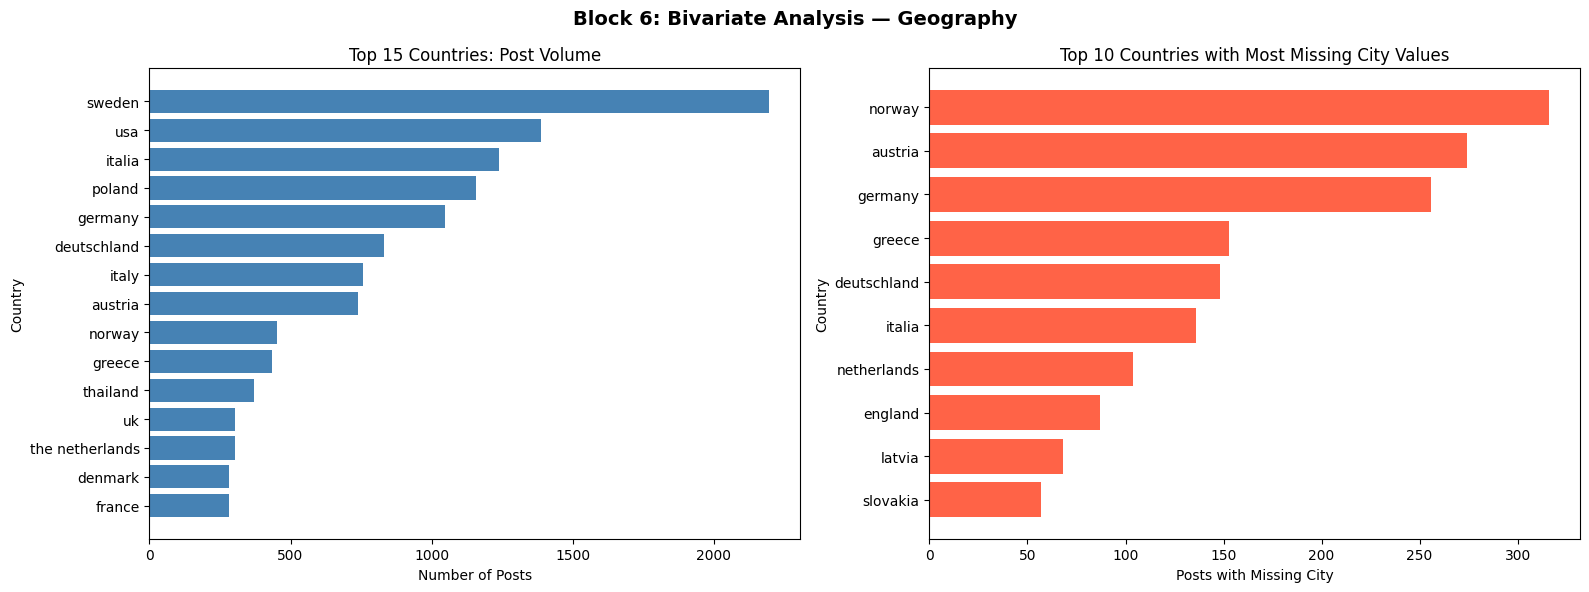


Block 6 chart saved.


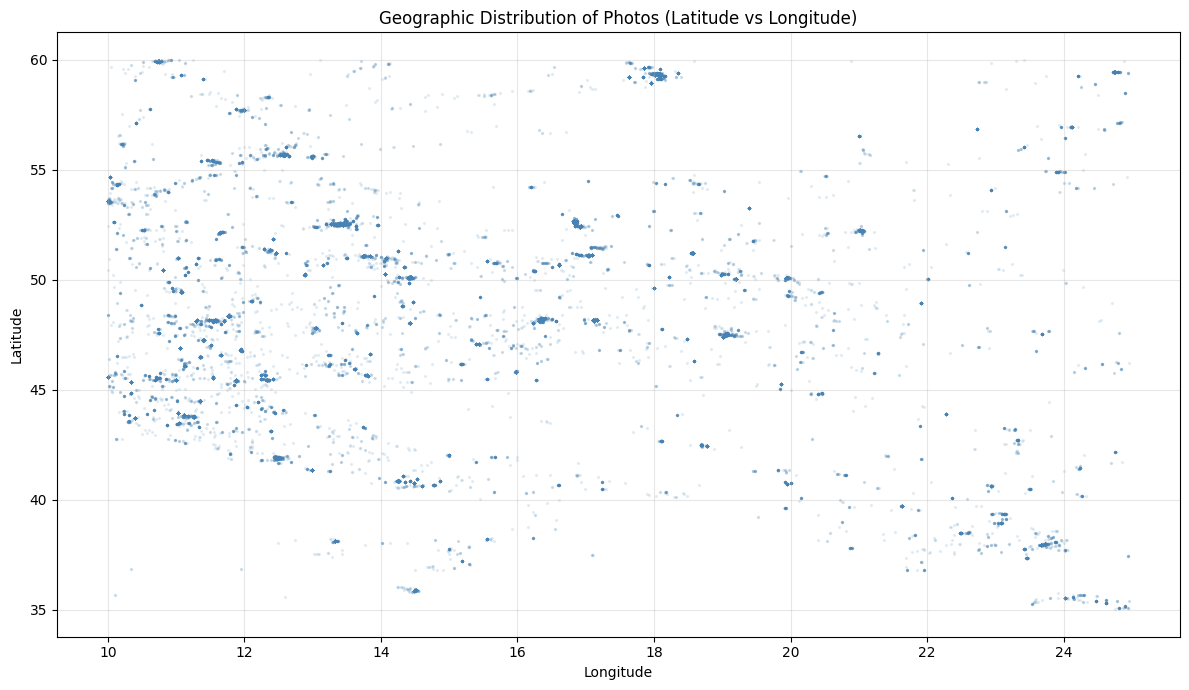

Block 6 scatter saved.


In [7]:
# ── BLOCK 6: Bivariate — Geography ────────────────────────────────

# 6.1 Missing City vs Country — are they missing together?
df_geo = df.copy()
df_geo['city_missing']    = (df_geo['City']    == 'NaN').astype(int)
df_geo['country_missing'] = (df_geo['Country'] == 'NaN').astype(int)

both_missing   = ((df_geo['City']=='NaN') & (df_geo['Country']=='NaN')).sum()
city_only_miss = ((df_geo['City']=='NaN') & (df_geo['Country']!='NaN')).sum()
country_only_miss = ((df_geo['City']!='NaN') & (df_geo['Country']=='NaN')).sum()
both_present   = ((df_geo['City']!='NaN') & (df_geo['Country']!='NaN')).sum()

print("=== BLOCK 6: City / Country Missingness Crosstab ===")
print(f"Both present        : {both_present:,}  ({both_present/len(df)*100:.1f}%)")
print(f"Both missing        : {both_missing:,} ({both_missing/len(df)*100:.1f}%)")
print(f"City missing only   : {city_only_miss:,} ({city_only_miss/len(df)*100:.1f}%)")
print(f"Country missing only: {country_only_miss:,} ({country_only_miss/len(df)*100:.1f}%)")

# 6.2 Top countries with most missing city data
print("\n=== Top 10 Countries with Most Missing City ===")
has_country   = df_geo[df_geo['Country'] != 'NaN']
city_miss_by_country = has_country[has_country['City'] == 'NaN']['Country'].value_counts().head(10)
print(city_miss_by_country.to_string())

# 6.3 Posts per Country — scatter of coordinate density by country
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Block 6: Bivariate Analysis — Geography', fontsize=14, fontweight='bold')

# Top 15 countries bar chart
country_counts = df[df['Country'] != 'NaN']['Country'].value_counts().head(15)
axes[0].barh(country_counts.index[::-1], country_counts.values[::-1], color='steelblue')
axes[0].set_title('Top 15 Countries: Post Volume')
axes[0].set_xlabel('Number of Posts')
axes[0].set_ylabel('Country')

# City missingness by country (top 10)
axes[1].barh(city_miss_by_country.index[::-1], city_miss_by_country.values[::-1], color='tomato')
axes[1].set_title('Top 10 Countries with Most Missing City Values')
axes[1].set_xlabel('Posts with Missing City')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.savefig('block6_geography.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nBlock 6 chart saved.")

# 6.4 Geographic scatter plot
fig2, ax = plt.subplots(figsize=(12, 7))
df_coords = df.copy()
df_coords['Latitude']  = pd.to_numeric(df_coords['Latitude'].replace('NaN', np.nan), errors='coerce')
df_coords['Longitude'] = pd.to_numeric(df_coords['Longitude'].replace('NaN', np.nan), errors='coerce')
df_coords = df_coords.dropna(subset=['Latitude','Longitude'])

ax.scatter(df_coords['Longitude'], df_coords['Latitude'],
           alpha=0.1, s=2, color='steelblue')
ax.set_title('Geographic Distribution of Photos (Latitude vs Longitude)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('block6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Block 6 scatter saved.")

## Block 7 — Bivariate: Time

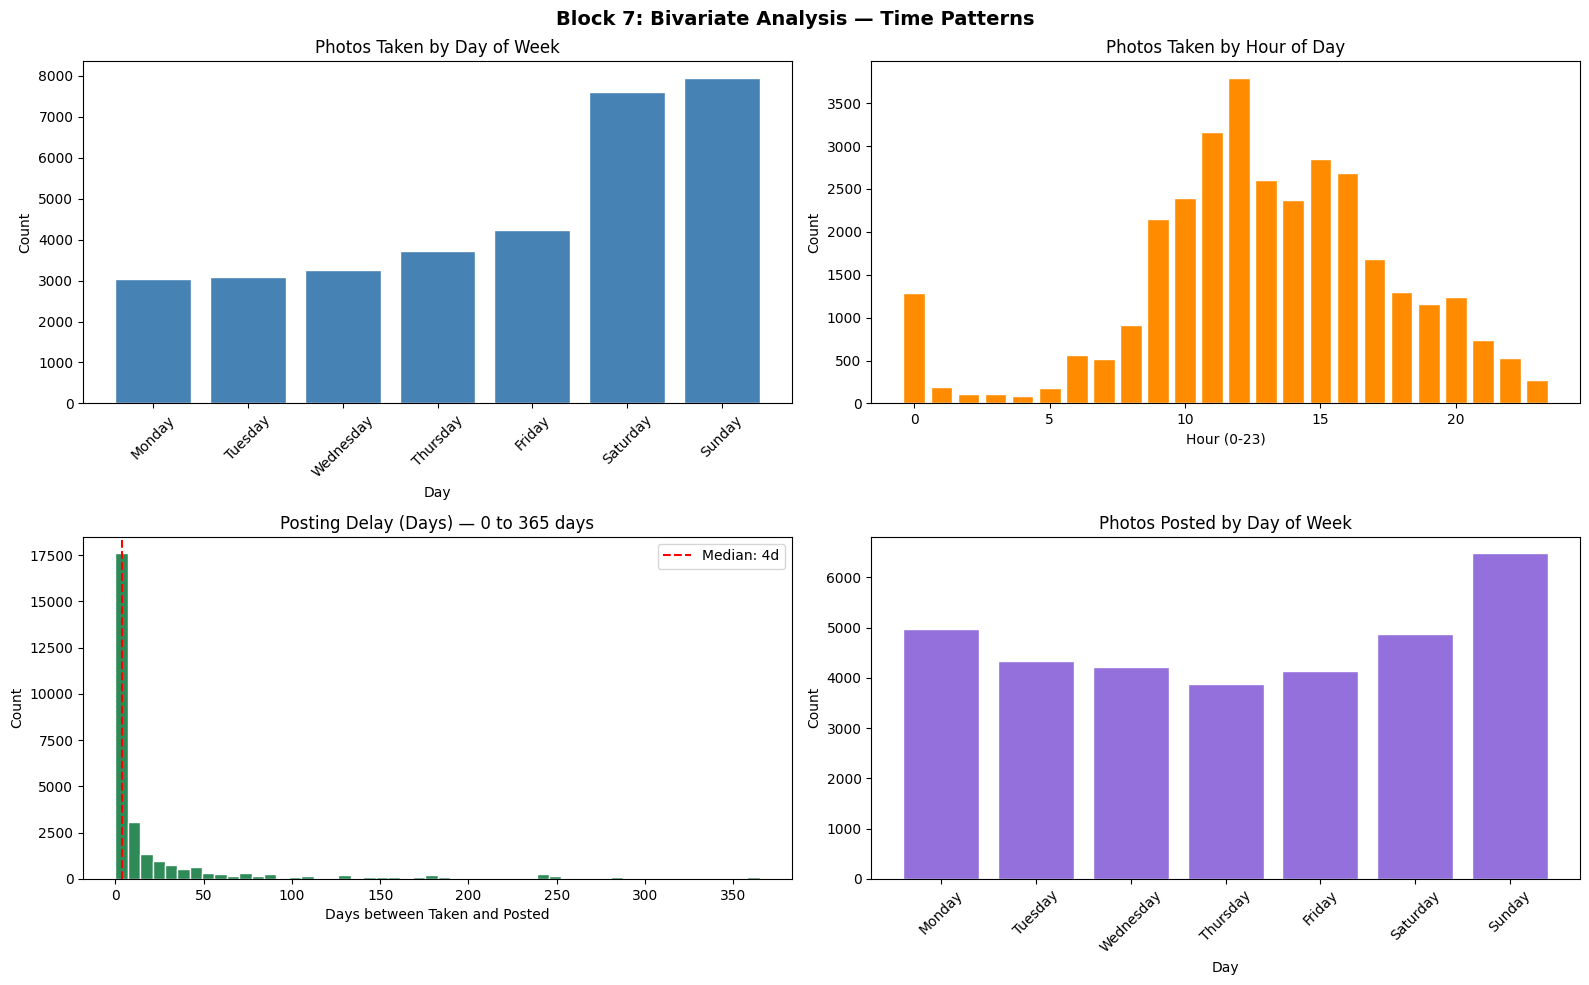

Block 7 chart saved.

=== BLOCK 7: Time Pattern Summary ===

Photos Taken by Day of Week:
Taken_DayOfWeek
Monday       3034
Tuesday      3082
Wednesday    3265
Thursday     3727
Friday       4231
Saturday     7596
Sunday       7956

Photos Posted by Day of Week:
Post_DayOfWeek
Monday       4965
Tuesday      4333
Wednesday    4227
Thursday     3872
Friday       4142
Saturday     4868
Sunday       6485

Photos Taken by Hour (top 5 peak hours):
Taken_Hour
12.0    3798
11.0    3164
15.0    2845
16.0    2681
13.0    2601

Posting delay (0-365 days only):
  Median : 4 days
  Mean   : 27.2 days
  % same day (0)    : 28.4%
  % within 7 days   : 61.1%
  % within 30 days  : 80.4%


In [8]:
# ── BLOCK 7: Bivariate — Time Analysis ────────────────────────────

df_time = df.copy()
df_time['Post_Date']  = pd.to_datetime(df_time['Post_Date'],  errors='coerce')
df_time['Taken_Date'] = pd.to_datetime(df_time['Taken_Date'], errors='coerce')
df_time['Posting_Delay_Days'] = (df_time['Post_Date'] - df_time['Taken_Date']).dt.days
df_time['Taken_DayOfWeek']   = df_time['Taken_Date'].dt.day_name()
df_time['Post_DayOfWeek']    = df_time['Post_Date'].dt.day_name()
df_time['Taken_Hour']        = df_time['Taken_Date'].dt.hour

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Block 7: Bivariate Analysis — Time Patterns', fontsize=14, fontweight='bold')

# 7.1 Photos taken by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
taken_dow = df_time['Taken_DayOfWeek'].value_counts().reindex(dow_order)
axes[0, 0].bar(dow_order, taken_dow.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Photos Taken by Day of Week')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 7.2 Photos taken by hour of day
taken_hour = df_time['Taken_Hour'].value_counts().sort_index()
axes[0, 1].bar(taken_hour.index, taken_hour.values, color='darkorange', edgecolor='white')
axes[0, 1].set_title('Photos Taken by Hour of Day')
axes[0, 1].set_xlabel('Hour (0-23)')
axes[0, 1].set_ylabel('Count')

# 7.3 Posting delay distribution (zoomed 0-365 days)
valid_delay = df_time['Posting_Delay_Days'].dropna()
valid_delay = valid_delay[(valid_delay >= 0) & (valid_delay <= 365)]
axes[1, 0].hist(valid_delay, bins=52, color='seagreen', edgecolor='white')
axes[1, 0].set_title('Posting Delay (Days) — 0 to 365 days')
axes[1, 0].set_xlabel('Days between Taken and Posted')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(valid_delay.median(), color='red', linestyle='--',
                   label=f'Median: {valid_delay.median():.0f}d')
axes[1, 0].legend()

# 7.4 Posting day of week
post_dow = df_time['Post_DayOfWeek'].value_counts().reindex(dow_order)
axes[1, 1].bar(dow_order, post_dow.values, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Photos Posted by Day of Week')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('block7_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Block 7 chart saved.")

print("\n=== BLOCK 7: Time Pattern Summary ===")
print("\nPhotos Taken by Day of Week:")
print(taken_dow.to_string())
print("\nPhotos Posted by Day of Week:")
print(post_dow.to_string())
print("\nPhotos Taken by Hour (top 5 peak hours):")
print(taken_hour.sort_values(ascending=False).head(5).to_string())
print(f"\nPosting delay (0-365 days only):")
print(f"  Median : {valid_delay.median():.0f} days")
print(f"  Mean   : {valid_delay.mean():.1f} days")
print(f"  % same day (0)    : {(valid_delay==0).sum()/len(valid_delay)*100:.1f}%")
print(f"  % within 7 days   : {(valid_delay<=7).sum()/len(valid_delay)*100:.1f}%")
print(f"  % within 30 days  : {(valid_delay<=30).sum()/len(valid_delay)*100:.1f}%")

## Block 8 — Bivariate: User behaviour

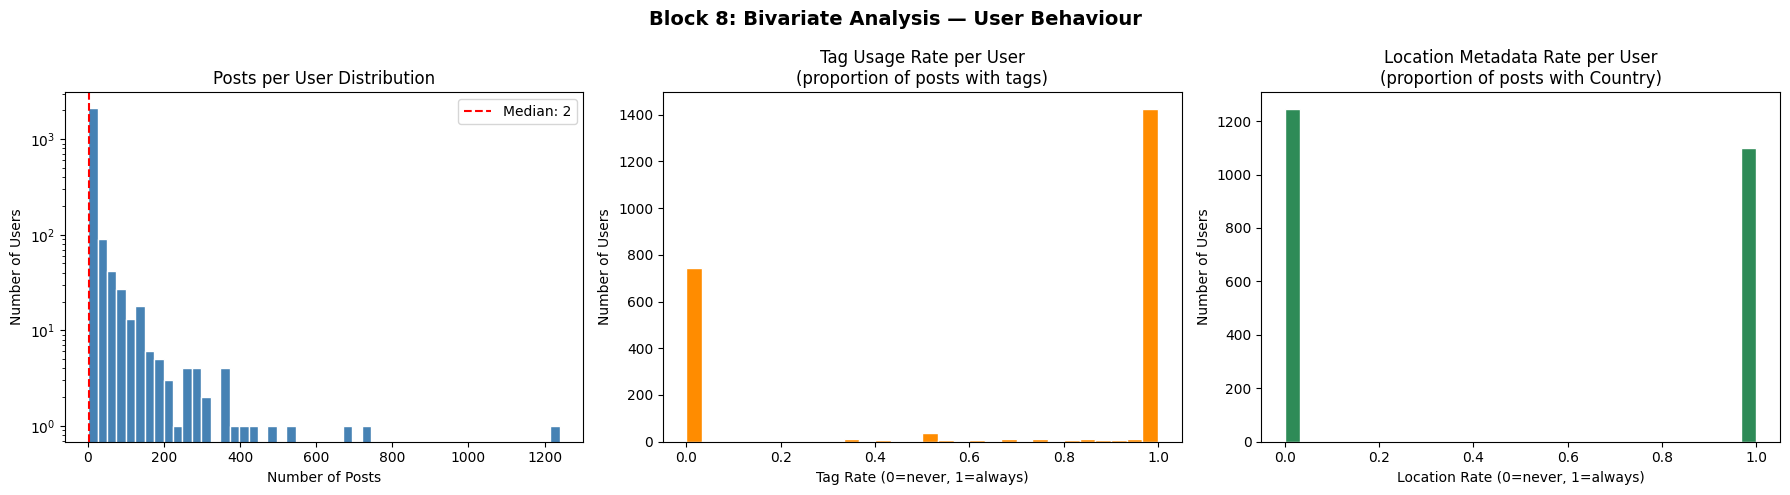

Block 8 chart saved.

=== BLOCK 8: User Behaviour Summary ===

Total unique users: 2,346

Post count per user:
  Median : 2
  Mean   : 14.0
  Max    : 1240
  Users with only 1 post  : 840 (35.8%)
  Users with 10+ posts    : 494 (21.1%)
  Users with 100+ posts   : 69 (2.9%)

Tag usage rate per user:
  Always tags (rate=1.0)  : 1,419 (60.5%)
  Never tags (rate=0.0)   : 740 (31.5%)
  Median tag rate         : 1.00

Location metadata rate per user:
  Always has location (1.0): 1,100 (46.9%)
  Never has location (0.0) : 1,246 (53.1%)
  Median location rate     : 0.00

Top 10 most active users:
      User_ID  post_count  tag_rate  location_rate
 60257816@N07        1240  1.000000            1.0
 84259626@N02         725  1.000000            0.0
 99117185@N00         671  1.000000            1.0
148026148@N07         532  0.849624            0.0
 65311653@N05         491  1.000000            1.0
 63979425@N05         442  0.000000            0.0
 15632944@N00         399  1.000000            

In [9]:
# ── BLOCK 8: Bivariate — User Behaviour ───────────────────────────

user_stats = df[df['User_ID'] != 'NaN'].groupby('User_ID').agg(
    post_count  = ('Post_ID',  'count'),
    has_tags    = ('Tags',     lambda x: (x != 'NaN').sum()),
    has_desc    = ('Description', lambda x: (x != 'NaN').sum()),
    has_city    = ('City',     lambda x: (x != 'NaN').sum()),
    has_country = ('Country',  lambda x: (x != 'NaN').sum()),
).reset_index()

user_stats['tag_rate']     = user_stats['has_tags']    / user_stats['post_count']
user_stats['desc_rate']    = user_stats['has_desc']    / user_stats['post_count']
user_stats['location_rate']= user_stats['has_country'] / user_stats['post_count']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Block 8: Bivariate Analysis — User Behaviour', fontsize=14, fontweight='bold')

# 8.1 Post count distribution (log scale)
axes[0].hist(user_stats['post_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Posts per User Distribution')
axes[0].set_xlabel('Number of Posts')
axes[0].set_ylabel('Number of Users')
axes[0].set_yscale('log')
axes[0].axvline(user_stats['post_count'].median(), color='red', linestyle='--',
                label=f"Median: {user_stats['post_count'].median():.0f}")
axes[0].legend()

# 8.2 Tag rate per user
axes[1].hist(user_stats['tag_rate'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Tag Usage Rate per User\n(proportion of posts with tags)')
axes[1].set_xlabel('Tag Rate (0=never, 1=always)')
axes[1].set_ylabel('Number of Users')

# 8.3 Location rate per user
axes[2].hist(user_stats['location_rate'], bins=30, color='seagreen', edgecolor='white')
axes[2].set_title('Location Metadata Rate per User\n(proportion of posts with Country)')
axes[2].set_xlabel('Location Rate (0=never, 1=always)')
axes[2].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('block8_users.png', dpi=150, bbox_inches='tight')
plt.show()
print("Block 8 chart saved.")

print("\n=== BLOCK 8: User Behaviour Summary ===")
print(f"\nTotal unique users: {len(user_stats):,}")
print(f"\nPost count per user:")
print(f"  Median : {user_stats['post_count'].median():.0f}")
print(f"  Mean   : {user_stats['post_count'].mean():.1f}")
print(f"  Max    : {user_stats['post_count'].max()}")
print(f"  Users with only 1 post  : {(user_stats['post_count']==1).sum():,} ({(user_stats['post_count']==1).sum()/len(user_stats)*100:.1f}%)")
print(f"  Users with 10+ posts    : {(user_stats['post_count']>=10).sum():,} ({(user_stats['post_count']>=10).sum()/len(user_stats)*100:.1f}%)")
print(f"  Users with 100+ posts   : {(user_stats['post_count']>=100).sum():,} ({(user_stats['post_count']>=100).sum()/len(user_stats)*100:.1f}%)")

print(f"\nTag usage rate per user:")
print(f"  Always tags (rate=1.0)  : {(user_stats['tag_rate']==1.0).sum():,} ({(user_stats['tag_rate']==1.0).sum()/len(user_stats)*100:.1f}%)")
print(f"  Never tags (rate=0.0)   : {(user_stats['tag_rate']==0.0).sum():,} ({(user_stats['tag_rate']==0.0).sum()/len(user_stats)*100:.1f}%)")
print(f"  Median tag rate         : {user_stats['tag_rate'].median():.2f}")

print(f"\nLocation metadata rate per user:")
print(f"  Always has location (1.0): {(user_stats['location_rate']==1.0).sum():,} ({(user_stats['location_rate']==1.0).sum()/len(user_stats)*100:.1f}%)")
print(f"  Never has location (0.0) : {(user_stats['location_rate']==0.0).sum():,} ({(user_stats['location_rate']==0.0).sum()/len(user_stats)*100:.1f}%)")
print(f"  Median location rate     : {user_stats['location_rate'].median():.2f}")

print(f"\nTop 10 most active users:")
print(user_stats.nlargest(10, 'post_count')[['User_ID','post_count','tag_rate','location_rate']].to_string(index=False))

## Block 9 — Multivariate

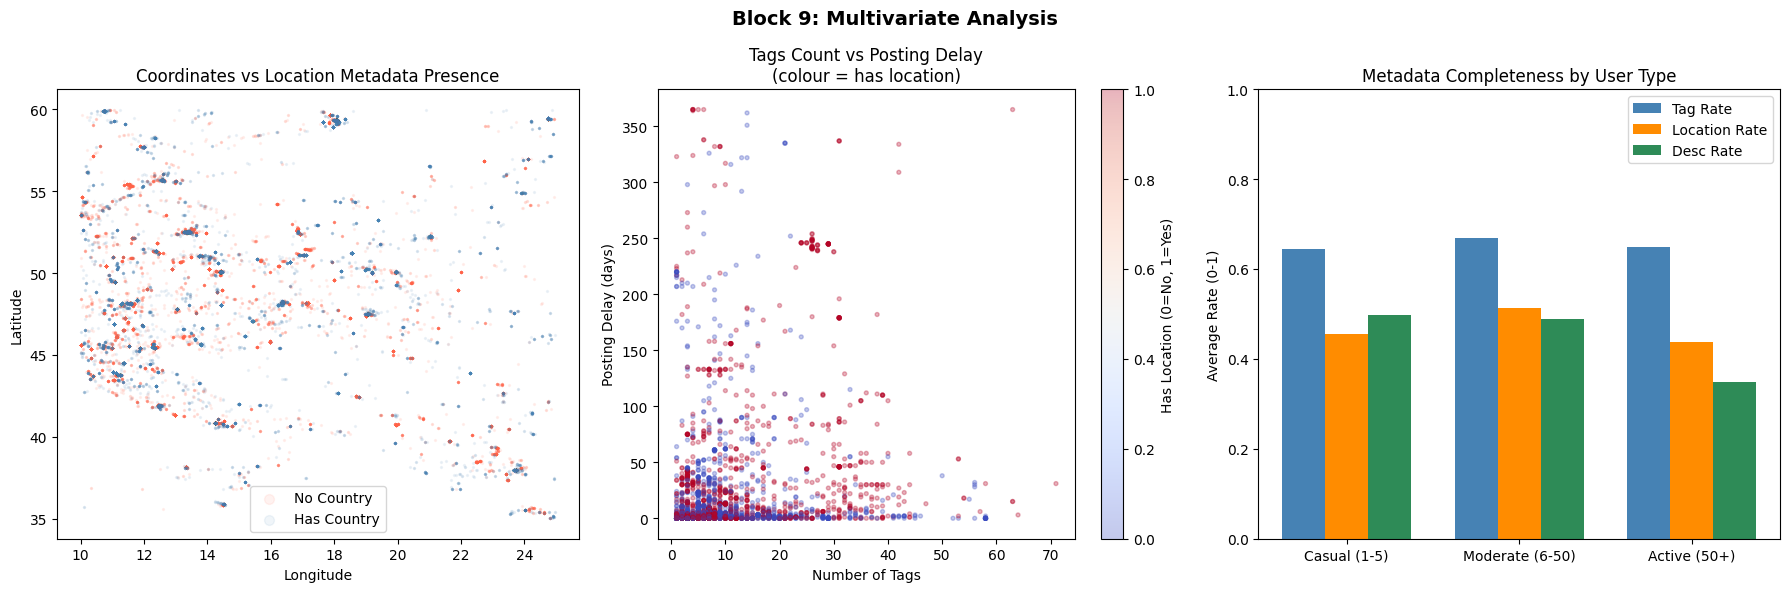

Block 9 chart saved.

=== BLOCK 9: Metadata Completeness by User Type ===
                 avg_tags  avg_location  avg_desc
user_type                                        
Casual (1-5)        0.643         0.455     0.498
Moderate (6-50)     0.669         0.514     0.489
Active (50+)        0.650         0.438     0.349

=== BLOCK 9: Correlation — Tags Count vs Posting Delay ===
               Tags_Count  Posting_Delay  Has_Location  Has_Tags
Tags_Count          1.000          0.170         0.058       NaN
Posting_Delay       0.170          1.000         0.132       NaN
Has_Location        0.058          0.132         1.000       NaN
Has_Tags              NaN            NaN           NaN       NaN


In [10]:
# ── BLOCK 9: Multivariate Analysis ────────────────────────────────

df_multi = df.copy()
df_multi['Latitude']  = pd.to_numeric(df_multi['Latitude'].replace('NaN', np.nan),  errors='coerce')
df_multi['Longitude'] = pd.to_numeric(df_multi['Longitude'].replace('NaN', np.nan), errors='coerce')
df_multi['Post_Date'] = pd.to_datetime(df_multi['Post_Date'], errors='coerce')
df_multi['Taken_Date']= pd.to_datetime(df_multi['Taken_Date'], errors='coerce')
df_multi['Posting_Delay'] = (df_multi['Post_Date'] - df_multi['Taken_Date']).dt.days
df_multi['Tags_Count'] = df_multi['Tags'].apply(
    lambda x: len([t for t in x.split(',') if t.strip()]) if x != 'NaN' else np.nan)
df_multi['Has_Tags']     = (df_multi['Tags']    != 'NaN').astype(int)
df_multi['Has_Location'] = (df_multi['Country'] != 'NaN').astype(int)
df_multi['Has_Desc']     = (df_multi['Description'] != 'NaN').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Block 9: Multivariate Analysis', fontsize=14, fontweight='bold')

# 9.1 Geographic scatter coloured by Has_Location metadata
df_coords = df_multi.dropna(subset=['Latitude','Longitude'])
has_loc  = df_coords[df_coords['Has_Location']==1]
no_loc   = df_coords[df_coords['Has_Location']==0]
axes[0].scatter(no_loc['Longitude'],  no_loc['Latitude'],  alpha=0.08, s=2, color='tomato',    label='No Country')
axes[0].scatter(has_loc['Longitude'], has_loc['Latitude'], alpha=0.08, s=2, color='steelblue', label='Has Country')
axes[0].set_title('Coordinates vs Location Metadata Presence')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(markerscale=5)

# 9.2 Posting delay vs Tags Count (sampled)
valid = df_multi.dropna(subset=['Posting_Delay','Tags_Count'])
valid = valid[(valid['Posting_Delay']>=0) & (valid['Posting_Delay']<=365)]
sample = valid.sample(min(3000, len(valid)), random_state=42)
sc = axes[1].scatter(sample['Tags_Count'], sample['Posting_Delay'],
                     alpha=0.3, s=8, c=sample['Has_Location'],
                     cmap='coolwarm')
axes[1].set_title('Tags Count vs Posting Delay\n(colour = has location)')
axes[1].set_xlabel('Number of Tags')
axes[1].set_ylabel('Posting Delay (days)')
plt.colorbar(sc, ax=axes[1], label='Has Location (0=No, 1=Yes)')

# 9.3 Metadata completeness profile per user cluster
user_meta = df_multi.groupby('User_ID').agg(
    posts         = ('Post_ID',       'count'),
    avg_tags      = ('Has_Tags',      'mean'),
    avg_location  = ('Has_Location',  'mean'),
    avg_desc      = ('Has_Desc',      'mean'),
).reset_index()
# Bin users into casual (1-5 posts), moderate (6-50), active (50+)
user_meta['user_type'] = pd.cut(user_meta['posts'],
    bins=[0,5,50,10000], labels=['Casual (1-5)','Moderate (6-50)','Active (50+)'])
profile = user_meta.groupby('user_type', observed=True)[['avg_tags','avg_location','avg_desc']].mean()

x = np.arange(3)
w = 0.25
axes[2].bar(x-w,   profile['avg_tags'],     w, label='Tag Rate',      color='steelblue')
axes[2].bar(x,     profile['avg_location'], w, label='Location Rate', color='darkorange')
axes[2].bar(x+w,   profile['avg_desc'],     w, label='Desc Rate',     color='seagreen')
axes[2].set_xticks(x)
axes[2].set_xticklabels(profile.index)
axes[2].set_title('Metadata Completeness by User Type')
axes[2].set_ylabel('Average Rate (0-1)')
axes[2].set_ylim(0,1)
axes[2].legend()

plt.tight_layout()
plt.savefig('block9_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Block 9 chart saved.")

print("\n=== BLOCK 9: Metadata Completeness by User Type ===")
print(profile.round(3).to_string())

print("\n=== BLOCK 9: Correlation — Tags Count vs Posting Delay ===")
corr = valid[['Tags_Count','Posting_Delay','Has_Location','Has_Tags']].corr().round(3)
print(corr.to_string())